In [108]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
from intersect_detection import get_bounding_boxes

In [109]:
image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
image_path = "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg"
# image_path = "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg"
model_path = "runs/detect/tune/weights/best.pt"

image = Image.open(image_path)
draw = ImageDraw.Draw(image)

bounding_boxes = get_bounding_boxes(image_path, model_path)
vertices = []
for box in bounding_boxes:
    x_center = (box[0] + box[2]) / 2
    y_center = (box[1] + box[3]) / 2
    vertices.append((x_center, y_center))
    draw.rectangle(box, outline="lime", width=5)
vertices = np.array(vertices)

# Display
# fig = plt.subplot()
# fig.imshow(image)
# fig.set_title(f"{image_path}")
# fig.axis('off')

Vh matrix:
 [[    0.87808    -0.47852]
 [   -0.47852    -0.87808]]


Text(0.5, 1.0, 'original image')

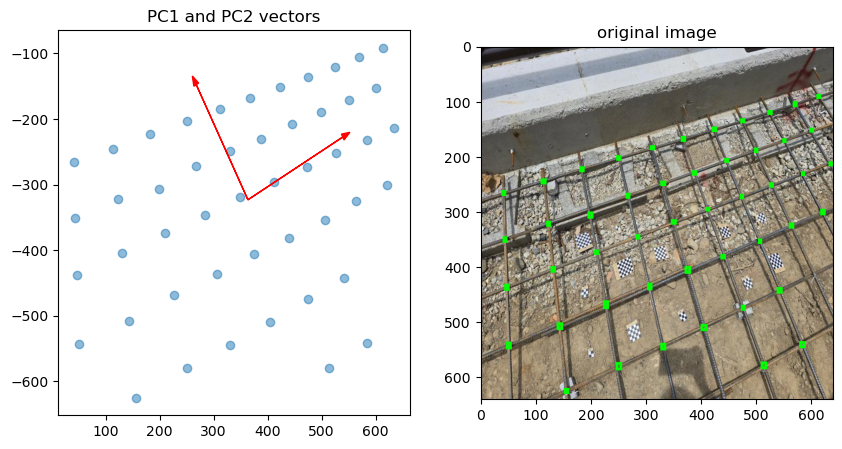

In [110]:
# Remove outliers
mean = np.mean(vertices, axis=0)
std = np.std(vertices, axis=0)
z_scores = np.abs((vertices - mean) / std)
vertices = vertices[(z_scores < 3).all(axis=1)]

# PCA Alignment
vc = vertices - mean
U, S, Vh = np.linalg.svd(vc) # 3 factors of matrix
# vr = vc @ Vh.T

# print("U matrix:\n", U) # Orthogonal matrix (rotate)
# print("U matrix shape:", U.shape)
# print("Singular values:\n", S) # Diagonal matrix (stretch)
print("Vh matrix:\n", Vh) # Orthogonal matrix (rotate)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title('PC1 and PC2 vectors')
plt.scatter(vertices[:, 0], -vertices[:, 1], alpha=0.5)
plt.arrow(mean[0], -mean[1], Vh[0, 0] * 200, -Vh[0, 1] * 200, color='r', head_width=10)
plt.arrow(mean[0], -mean[1], Vh[1, 0] * 200, -Vh[1, 1] * 200, color='r', head_width=10)
plt.subplot(1,2,2)
plt.imshow(image)
plt.title('original image')
# plt.scatter(vr[:, 0], vr[:, 1], alpha=0.5)

In [135]:
import math as m

def rotate(vector, angle):
    [x, y] = vector
    angler = angle * m.pi / 180
    newx = x * m.cos(angler) - y * m.sin(angler)
    newy = x * m.sin(angler) + y * m.cos(angler)
    return [newx, newy]


def vector_span(vector, angle):
    """
    Creates a span (cone) around a given vector by rotating it by ±angle degrees.
    
    This function takes a 2D vector and creates two boundary vectors by rotating
    the original vector clockwise and counterclockwise by the specified angle.
    The resulting span represents a cone or wedge shape that can be used to
    check if other vectors fall within this angular range.
    
    Args:
        vector (list or np.array): A 2D vector [x, y] that serves as the center direction
        angle (float): The rotation angle in degrees (±angle creates the span width)
                      For example, angle=10 creates a 20-degree cone (±10°)
    
    Returns:
        np.array: A 2x2 matrix where:
                 - First row: vector rotated by +angle degrees (counterclockwise)
                 - Second row: vector rotated by -angle degrees (clockwise)
                 
    Example:
        >>> span = vector_span([1, 0], 30)  # 30° rotation around horizontal vector
        >>> print(span)
        [[    0.86603,         0.5],  # [1,0] rotated +30° 
         [    0.86603,        -0.5]]  # [1,0] rotated -30°
    """
    # Rotate the input vector by +angle degrees (counterclockwise)
    positive_rotation = rotate(vector, angle)
    
    # Rotate the input vector by -angle degrees (clockwise) 
    negative_rotation = rotate(vector, -angle)
    
    # Stack the two rotated vectors vertically to form a 2x2 matrix
    # This matrix defines the boundary vectors of the span/cone
    return np.row_stack((positive_rotation, negative_rotation))


def is_vector_aligned_with_pc(vertex1, vertex2, principal_component, tolerance_angle):
    """
    Checks if the vector between two vertices aligns with a principal component within a tolerance angle.
    
    Args:
        vertex1 (np.array): First vertex coordinates [x, y] (start point)
        vertex2 (np.array): Second vertex coordinates [x, y] (end point)
        principal_component (np.array): Principal component vector [x, y] from PCA
        tolerance_angle (float): Angular tolerance in degrees (±tolerance creates acceptance cone)
    
    Returns:
        bool: True if vector from vertex1 to vertex2 is within the acceptance cone, False otherwise

    Example:
        >>> is_vector_aligned_with_pc([0, 0], [0.9, 0.2], [1, 0], 30)  # Check if vector is within ±30° of x-axis
        True
        >>> is_vector_aligned_with_pc([0, 0], [0.2, 0.9], [1, 0], 30)  # Vector at ~77° from x-axis
        False
    """
    # Calculate the direction vector from vertex1 to vertex2
    direction_vector = np.array(vertex2) - np.array(vertex1)
    
    # Create the span (cone boundaries) by rotating the principal component vector ±angle degrees
    span = vector_span(principal_component, tolerance_angle)

    try:
        x, y = np.linalg.solve(span, direction_vector)
        return x >= 0 and y >= 0
        
    except np.linalg.LinAlgError:
        return False

In [138]:
# pc1 = Vh[0]
# pc2 = Vh[1]

# pc1_span = vector_span(pc1, 10)
# pc2_span = vector_span(pc2, 10)

# pc1_span, pc2_span

# span = vector_span([1, 0], 10)
# is_in_span([0.1, 0], [1, 0], 10)
# is_vector_aligned_with_pc([0.9, 0.2], [1, 0], 30), is_vector_aligned_with_pc([0.2, 0.9], [1, 0], 30)
is_vector_aligned_with_pc([0, 0], [0.9, 0.2], [1, 0], 30), is_vector_aligned_with_pc([0, 0], [0.2, 0.9], [1, 0], 30)

# vector_span([1, 0], 30)


# used_vertices = set()
# for vertex in vertices:
#     if tuple(vertex) in used_vertices:
#         continue
    
    

(True, False)